In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
PROJECT_ROOT = r"D:\TrustXAI"

MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "models",
    "Improved_RandomForest_TrustXAI.pkl"
)

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "ready",
    "TrustXAI_Balanced.csv"
)

RESULT_PATH = os.path.join(
    PROJECT_ROOT,
    "results"
)

os.makedirs(RESULT_PATH, exist_ok=True)

print("Paths Ready.")

Paths Ready.


In [3]:
print("Loading Model...")

rf_model = joblib.load(MODEL_PATH)

print("Loading Dataset...")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)

Loading Model...
Loading Dataset...
Dataset Shape: (49115, 85)


In [4]:
columns_to_remove = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

X = df.drop(columns=columns_to_remove + ["Label"], errors="ignore")
y = df["Label"]

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (49115, 80)
Labels Shape   : (49115,)


In [5]:
explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in sorted(y.unique())],
    mode="classification",
    random_state=42
)

print("LIME Explainer Ready!")

LIME Explainer Ready!


In [6]:
sample_index = 0

exp = explainer.explain_instance(
    X.iloc[sample_index].values,
    rf_model.predict_proba,
    num_features=15
)

print("Explanation Created Successfully!")

Explanation Created Successfully!


C:\Users\2023\anaconda3\envs\trustxai\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


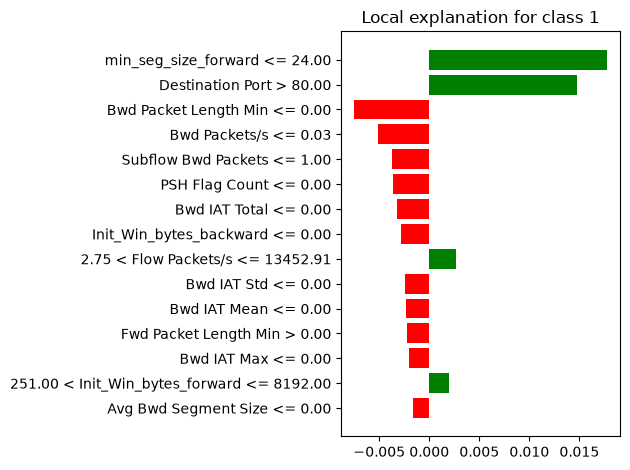

LIME Figure Displayed Successfully!


In [7]:
fig = exp.as_pyplot_figure()

plt.tight_layout()

plt.show()

print("LIME Figure Displayed Successfully!")

In [8]:
html_path = os.path.join(
    RESULT_PATH,
    "LIME_Explanation.html"
)

exp.save_to_file(html_path)

print("HTML Saved Successfully!")

HTML Saved Successfully!


In [9]:
lime_features = pd.DataFrame(
    exp.as_list(),
    columns=["Feature", "Weight"]
)

lime_features

,Feature,Weight
0,min_seg_size_forward <= 24.00,0.017789
1,Destination Port > 80.00,0.014803
2,Bwd Packet Length Min <= 0.00,-0.007537
3,Bwd Packets/s <= 0.03,-0.005131
4,Subflow Bwd Packets <= 1.00,-0.003756
5,PSH Flag Count <= 0.00,-0.003578
6,Bwd IAT Total <= 0.00,-0.003209
7,Init_Win_bytes_backward <= 0.00,-0.002813
8,2.75 < Flow Packets/s <= 13452.91,0.002626
9,Bwd IAT Std <= 0.00,-0.002464


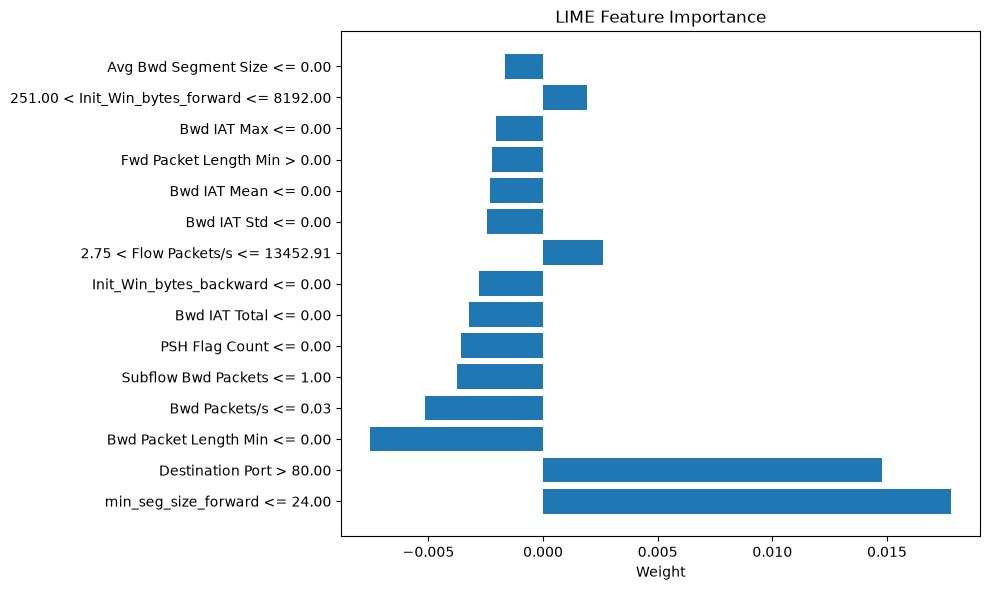

LIME Plot Saved Successfully!


In [10]:
plt.figure(figsize=(10,6))

plt.barh(
    lime_features["Feature"],
    lime_features["Weight"]
)

plt.title("LIME Feature Importance")

plt.xlabel("Weight")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_PATH,
        "LIME_Feature_Importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("LIME Plot Saved Successfully!")

In [11]:
lime_features.to_csv(
    os.path.join(
        RESULT_PATH,
        "LIME_Feature_Importance.csv"
    ),
    index=False
)

print(lime_features)

print("CSV Saved Successfully!")

                                       Feature    Weight
0                min_seg_size_forward <= 24.00  0.017789
1                     Destination Port > 80.00  0.014803
2                Bwd Packet Length Min <= 0.00 -0.007537
3                        Bwd Packets/s <= 0.03 -0.005131
4                  Subflow Bwd Packets <= 1.00 -0.003756
5                       PSH Flag Count <= 0.00 -0.003578
6                        Bwd IAT Total <= 0.00 -0.003209
7              Init_Win_bytes_backward <= 0.00 -0.002813
8            2.75 < Flow Packets/s <= 13452.91  0.002626
9                          Bwd IAT Std <= 0.00 -0.002464
10                        Bwd IAT Mean <= 0.00 -0.002319
11                Fwd Packet Length Min > 0.00 -0.002209
12                         Bwd IAT Max <= 0.00 -0.002069
13  251.00 < Init_Win_bytes_forward <= 8192.00  0.001934
14                Avg Bwd Segment Size <= 0.00 -0.001653
CSV Saved Successfully!
